In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print("Dataset loaded")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

All imports successful
/kaggle/input/datasets/girardi69/marathon-time-predictions/MarathonData.csv
Dataset loaded


In [2]:
df = pd.read_csv('/kaggle/input/datasets/girardi69/marathon-time-predictions/MarathonData.csv')

print(f'Shape of the dataset : {df.shape}')
# print(df.describe)
print(f'Columns in the dataset  \n{df.columns}')

Shape of the dataset : (87, 10)
Columns in the dataset  
Index(['id', 'Marathon', 'Name', 'Category', 'km4week', 'sp4week',
       'CrossTraining', 'Wall21', 'MarathonTime', 'CATEGORY'],
      dtype='object')


In [3]:
df.head()

,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,NaN,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,NaN,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,NaN,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,NaN,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,NaN,1.36,2.74,A


In [4]:
df.tail()

,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
82,83,Prague17,Stefano Vegliani,M55,50.0,10.830325,NaN,2.02,3.93,D
83,84,Prague17,Andrej Madliak,M40,33.6,10.130653,ciclista 3h,1.94,3.93,D
84,85,Prague17,Yoi Ohsako,M40,55.4,11.043189,NaN,1.94,3.94,D
85,86,Prague17,Simon Dunn,M45,33.2,11.066667,NaN,2.05,3.95,D
86,87,Prague17,Pavel ?imek,M40,17.9,10.848485,ciclista 5h,2.05,3.98,D


In [5]:

print(df.isnull().sum())
print("------------------------------------")
print(df.dtypes)
print("------------------------------------")
print(df['Category'].value_counts())
print("------------------------------------")
print(df['CATEGORY'].value_counts())
print("------------------------------------")

id                0
Marathon          0
Name              0
Category          6
km4week           0
sp4week           0
CrossTraining    74
Wall21            0
MarathonTime      0
CATEGORY          0
dtype: int64
------------------------------------
id                 int64
Marathon          object
Name              object
Category          object
km4week          float64
sp4week          float64
CrossTraining     object
Wall21            object
MarathonTime     float64
CATEGORY          object
dtype: object
------------------------------------
Category
MAM    40
M45    15
M40    15
M50     4
WAM     4
M55     3
Name: count, dtype: int64
------------------------------------
CATEGORY
B    28
A    21
C    21
D    17
Name: count, dtype: int64
------------------------------------


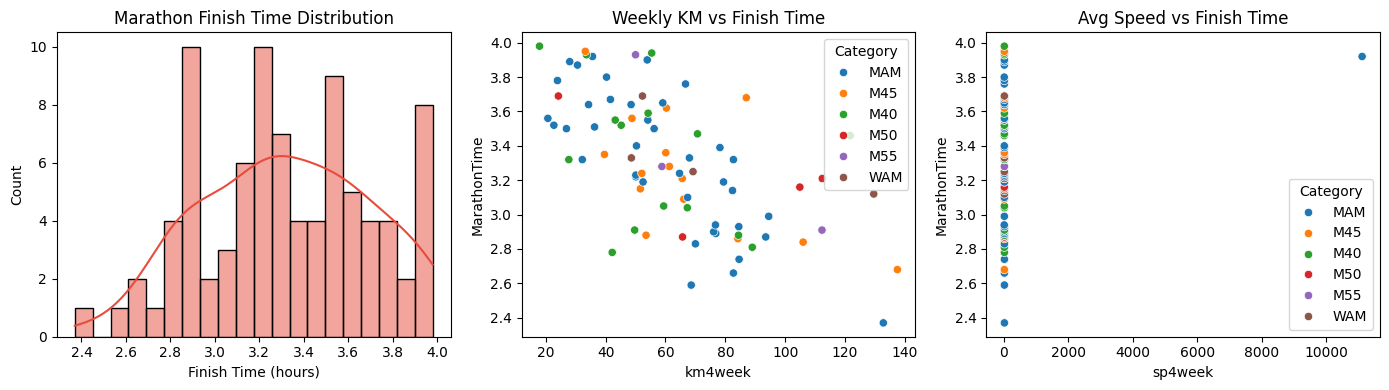

In [6]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['MarathonTime'], bins=20, kde=True, color='#e74c3c')
plt.title('Marathon Finish Time Distribution')
plt.xlabel('Finish Time (hours)')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='km4week', y='MarathonTime', hue='Category')
plt.title('Weekly KM vs Finish Time')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='sp4week', y='MarathonTime', hue='Category')
plt.title('Avg Speed vs Finish Time')

plt.tight_layout()
plt.show()


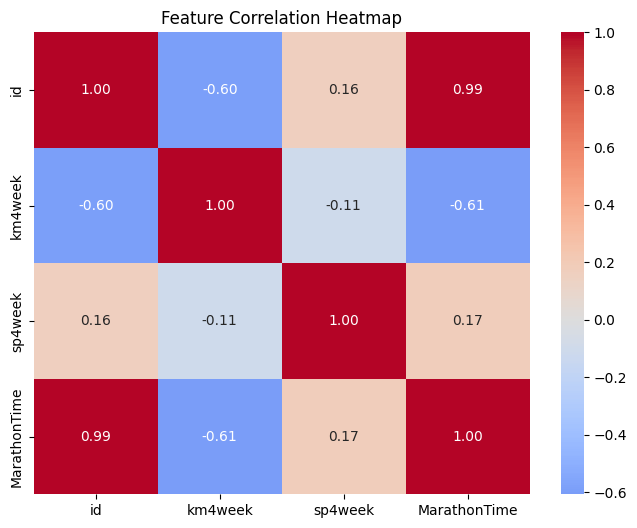

In [7]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [8]:
df = df.drop(columns=['id', 'Marathon', 'Name', 'CATEGORY'])
df.head()

,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime
0,MAM,132.8,14.434783,NaN,1.16,2.37
1,MAM,68.6,13.674419,NaN,1.23,2.59
2,MAM,82.7,13.520436,NaN,1.30,2.66
3,M45,137.5,12.258544,NaN,1.32,2.68
4,MAM,84.6,13.945055,NaN,1.36,2.74


In [9]:
print("sp4week stats BEFORE cleaning:")
print(df['sp4week'].describe())

sp4week stats BEFORE cleaning:
count       87.000000
mean       139.840706
std       1191.427864
min          8.031414
25%         11.498168
50%         12.163424
75%         12.854036
max      11125.000000
Name: sp4week, dtype: float64


In [10]:
print(f"\nOutliers (sp4week > 25 km/h): {(df['sp4week'] > 25).sum()}")


Outliers (sp4week > 25 km/h): 1


In [11]:
# capping the speed to 25km/hr
df = df[df['sp4week'] < 25]

print(f"\nShape after removing sp4week outliers: {df.shape}")
print(f"\nsp4week stats AFTER cleaning:")
print(df['sp4week'].describe())


Shape after removing sp4week outliers: (86, 6)

sp4week stats AFTER cleaning:
count    86.000000
mean     12.106296
std       1.202718
min       8.031414
25%      11.485348
50%      12.145932
75%      12.804061
max      14.970492
Name: sp4week, dtype: float64


In [12]:
df['did_cross_train'] = df['CrossTraining'].notna().astype(int)
df['did_cross_train']

df = df.drop(columns = ['CrossTraining'])

In [13]:
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nShape: {df.shape}")
print(f"\ndid_cross_train value counts:")
print(df['did_cross_train'].value_counts())

Missing values after cleaning:
Category           6
km4week            0
sp4week            0
Wall21             0
MarathonTime       0
did_cross_train    0
dtype: int64

Shape: (86, 6)

did_cross_train value counts:
did_cross_train
0    73
1    13
Name: count, dtype: int64


In [14]:
df.head(6)

,Category,km4week,sp4week,Wall21,MarathonTime,did_cross_train
0,MAM,132.8,14.434783,1.16,2.37,0
1,MAM,68.6,13.674419,1.23,2.59,0
2,MAM,82.7,13.520436,1.30,2.66,0
3,M45,137.5,12.258544,1.32,2.68,0
4,MAM,84.6,13.945055,1.36,2.74,0
5,M40,42.2,13.612903,1.32,2.78,0


In [15]:
df['speed_efficiency'] = df['sp4week'] * df['km4week']

In [16]:
print("Wall21 unique values:", df['Wall21'].unique())

Wall21 unique values: ['1.16' '1.23' '1.30' '1.32' '1.36' '1.38' '1.41' '1.35' '1.42' '1.40'
 '1.37' '1.44' '1.45' '1.50' '1.48' '1.52' ' -   ' '1.54' '1.57' '1.62'
 '1.60' '1.51' '1.58' '1.56' '1.61' '1.59' '1.68' '1.78' '1.67' '1.66'
 '1.55' '1.64' '1.65' '1.77' '1.71' '1.72' '1.76' '1.63' '1.69' '1.88'
 '1.93' '1.74' '1.75' '1.80' '1.81' '1.94' '1.90' '1.85' '1.97' '1.98'
 '2.02' '2.05']


In [17]:
df['Wall21'].replace(' -   ', '0')

0     1.16
1     1.23
2     1.30
3     1.32
4     1.36
      ... 
82    2.02
83    1.94
84    1.94
85    2.05
86    2.05
Name: Wall21, Length: 86, dtype: object

In [18]:
df['Wall21'] = pd.to_numeric(df['Wall21'], errors='coerce')

In [19]:
print(df['Wall21'].isnull().sum())

6


In [20]:
df['Wall21'] = df['Wall21'].fillna(0)

In [21]:
df['Wall21'].isnull().sum()

np.int64(0)

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

In [23]:
le.classes_

array(['M40', 'M45', 'M50', 'M55', 'MAM', 'WAM', nan], dtype=object)

In [24]:
print(f"\nFinal columns: {df.columns.tolist()}")
df.head()


Final columns: ['Category', 'km4week', 'sp4week', 'Wall21', 'MarathonTime', 'did_cross_train', 'speed_efficiency', 'Category_encoded']


,Category,km4week,sp4week,Wall21,MarathonTime,did_cross_train,speed_efficiency,Category_encoded
0,MAM,132.8,14.434783,1.16,2.37,0,1916.939131,4
1,MAM,68.6,13.674419,1.23,2.59,0,938.065116,4
2,MAM,82.7,13.520436,1.30,2.66,0,1118.140055,4
3,M45,137.5,12.258544,1.32,2.68,0,1685.549777,1
4,MAM,84.6,13.945055,1.36,2.74,0,1179.751649,4


In [25]:
print("\nCategory encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")


Category encoding mapping:
  M40 → 0
  M45 → 1
  M50 → 2
  M55 → 3
  MAM → 4
  WAM → 5
  nan → 6


In [26]:
most_common_category = df['Category'].mode()[0]
print(most_common_category)

MAM


In [27]:
df['Category'] = df['Category'].fillna(most_common_category)
df['Category_encoded'] = le.fit_transform(df['Category'])
print("\nCategory encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")



Category encoding mapping:
  M40 → 0
  M45 → 1
  M50 → 2
  M55 → 3
  MAM → 4
  WAM → 5


In [28]:
print(f"Nulls in Category: {df['Category'].isnull().sum()}")
print(f"Unique values: {df['Category'].unique()}")

Nulls in Category: 0
Unique values: ['MAM' 'M45' 'M40' 'M50' 'M55' 'WAM']


In [29]:
df.head()

,Category,km4week,sp4week,Wall21,MarathonTime,did_cross_train,speed_efficiency,Category_encoded
0,MAM,132.8,14.434783,1.16,2.37,0,1916.939131,4
1,MAM,68.6,13.674419,1.23,2.59,0,938.065116,4
2,MAM,82.7,13.520436,1.30,2.66,0,1118.140055,4
3,M45,137.5,12.258544,1.32,2.68,0,1685.549777,1
4,MAM,84.6,13.945055,1.36,2.74,0,1179.751649,4


In [30]:
features = ['km4week', 'sp4week', 'Wall21', 'did_cross_train', 
            'speed_efficiency', 'Category_encoded']

X = df[features]
Y = df['MarathonTime']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


# Scaling value to ensure the variance in the data is as close to 0
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [32]:
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 68
Test samples     : 18


In [33]:
import xgboost as xg
from xgboost import XGBRegressor

models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XG Boost' : XGBRegressor(params = {
                        'max_depth':6,
                        'learning_rate':0.1,
                        'n_estimators':200,
                        'reg_alpha':10})
}

results = dict()

In [34]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'model': model, 'preds': preds}
    print(f"{name:25s} | MAE: {mae:.4f}h | RMSE: {rmse:.4f}h | R²: {r2:.4f}")
    

Linear Regression         | MAE: 0.1805h | RMSE: 0.2303h | R²: 0.6979
Ridge Regression          | MAE: 0.1717h | RMSE: 0.2240h | R²: 0.7142
Random Forest             | MAE: 0.1309h | RMSE: 0.1779h | R²: 0.8197
Gradient Boosting         | MAE: 0.1199h | RMSE: 0.1524h | R²: 0.8678
XG Boost                  | MAE: 0.1410h | RMSE: 0.2101h | R²: 0.7484


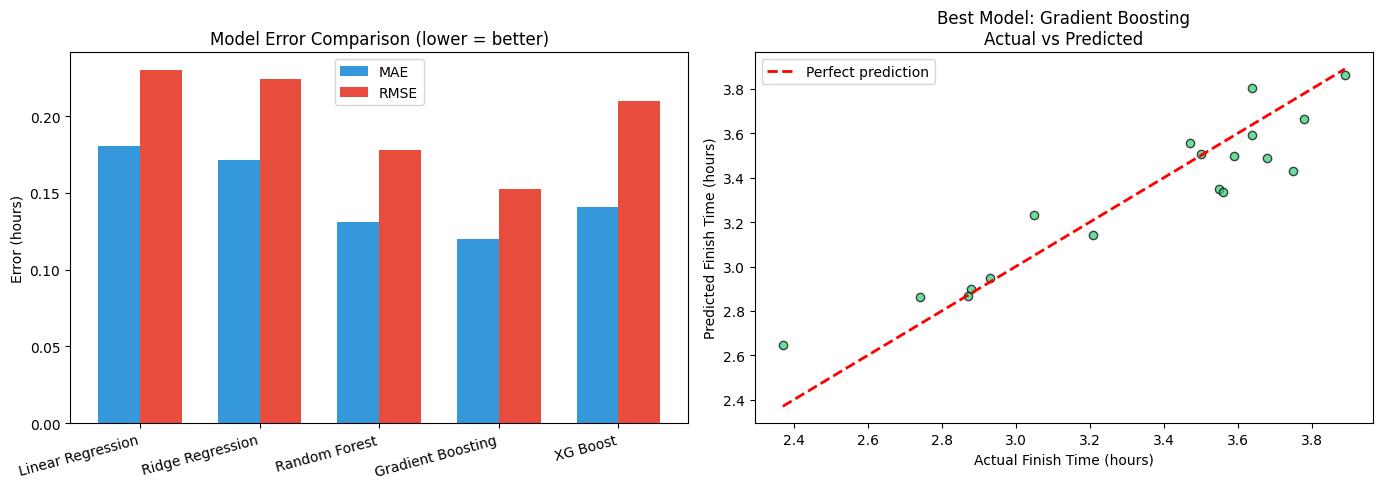


 Best model: Gradient Boosting with 
MAE = 0.1199 hours / 7.195731810553954 mins


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE + RMSE bar chart
model_names = list(results.keys())
maes  = [results[m]['MAE']  for m in model_names]
rmses = [results[m]['RMSE'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[0].bar(x - width/2, maes,  width, label='MAE',  color='#3498db')
axes[0].bar(x + width/2, rmses, width, label='RMSE', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('Error (hours)')
axes[0].set_title('Model Error Comparison (lower = better)')
axes[0].legend()

# Plot 2: Actual vs Predicted for best model
best_model_name = min(results, key=lambda m: results[m]['MAE'])
best_preds      = results[best_model_name]['preds']

axes[1].scatter(y_test, best_preds, color='#2ecc71', alpha=0.7, edgecolors='black')
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Finish Time (hours)')
axes[1].set_ylabel('Predicted Finish Time (hours)')
axes[1].set_title(f'Best Model: {best_model_name}\nActual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n Best model: {best_model_name} with \nMAE = {results[best_model_name]['MAE']:.4f} hours / {results[best_model_name]['MAE']*60} mins")

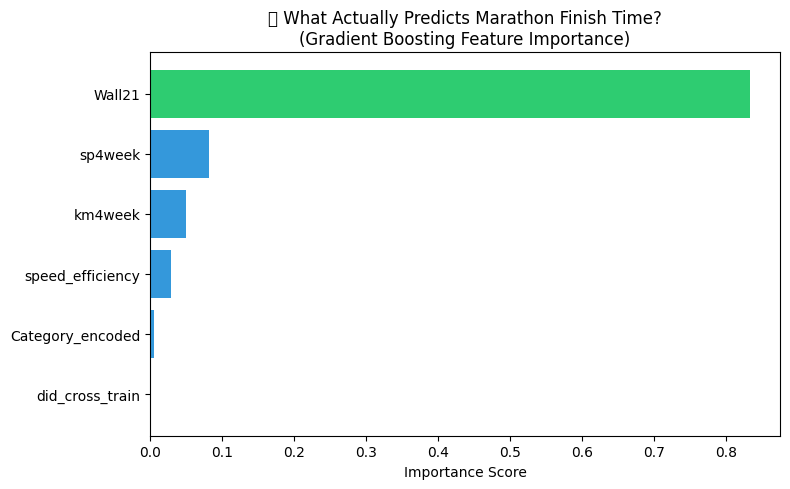


Feature Importance Ranking:
  Wall21               ███████████████████████████████████████████████████████████████████████████████████ 0.8333
  sp4week              ████████ 0.0813
  km4week              ████ 0.0496
  speed_efficiency     ██ 0.0289
  Category_encoded      0.0054
  did_cross_train       0.0015


In [36]:
# Gradient Boosting - feature importances
best_model = results['Gradient Boosting']['model']

importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color=['#2ecc71' if x == importance_df['Importance'].max() 
                       else '#3498db' for x in importance_df['Importance']])
plt.xlabel('Importance Score')
plt.title('🏃 What Actually Predicts Marathon Finish Time?\n(Gradient Boosting Feature Importance)')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:20s} {bar} {row['Importance']:.4f}")

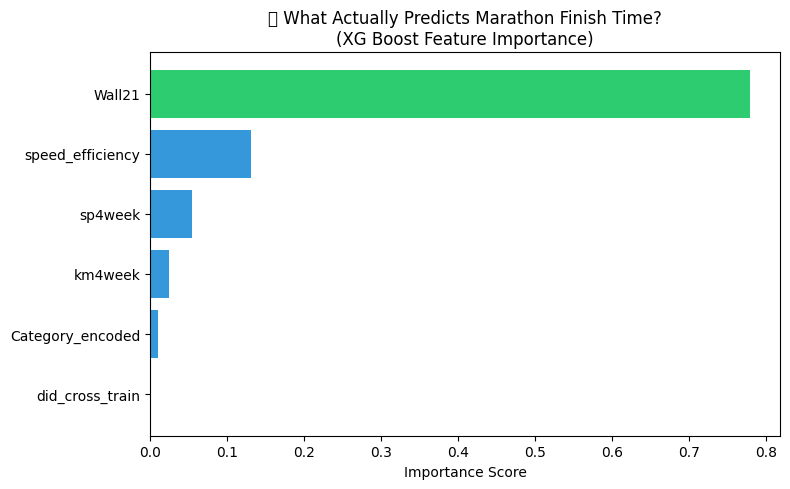


Feature Importance Ranking:
  Wall21               █████████████████████████████████████████████████████████████████████████████ 0.7788
  speed_efficiency     █████████████ 0.1314
  sp4week              █████ 0.0550
  km4week              ██ 0.0240
  Category_encoded      0.0097
  did_cross_train       0.0011


In [37]:
import xgboost as xgb

best_model = results['XG Boost']['model']

importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)


plt.figure(figsize=(8, 5))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color=['#2ecc71' if x == importance_df['Importance'].max() 
                       else '#3498db' for x in importance_df['Importance']])
plt.xlabel('Importance Score')
plt.title('🏃 What Actually Predicts Marathon Finish Time?\n(XG Boost Feature Importance)')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:20s} {bar} {row['Importance']:.4f}")

In [38]:

print("=" * 50)
print("🏃 MARATHON FINISH TIME PREDICTOR")
print("=" * 50)

# Define a new runner's profile
new_runner = pd.DataFrame({
    'km4week'          : [85],    # runs 85km/week
    'sp4week'          : [11.5],  # avg speed 11.5 km/h
    'Wall21'           : [1.2],   # slight wall at halfway
    'did_cross_train'  : [1],     # does cross training
    'speed_efficiency' : [65 * 11.5],
    'Category_encoded' : [le.transform(['MAM'])[0]]  # Male Amateur
})

new_runner_scaled = scaler.transform(new_runner)
predicted_time    = best_model.predict(new_runner_scaled)[0]
predicted_minutes = int((predicted_time % 1) * 60)
predicted_hours   = int(predicted_time)

print(f"\nRunner Profile:")
print(f"  Weekly mileage  : 85 km")
print(f"  Avg speed       : 11.5 km/h")
print(f"  Category        : Male Amateur")
print(f"  Cross training  : Yes")

print(f"\n🎯 Predicted Finish Time: {predicted_hours}h {predicted_minutes}min")
print(f"   (Raw: {predicted_time:.4f} hours)")

🏃 MARATHON FINISH TIME PREDICTOR

Runner Profile:
  Weekly mileage  : 85 km
  Avg speed       : 11.5 km/h
  Category        : Male Amateur
  Cross training  : Yes

🎯 Predicted Finish Time: 3h 15min
   (Raw: 3.2554 hours)
